# ML-Enabled IoT-Based Rubber Plantation Monitoring and Tapping Decision System
## Python / Machine-Learning Notebook

This notebook implements the Python-side requirements described in the Final
Project Report:

- Section 11 — Dataset Design
- Section 12 — Synthetic Dataset Creation
- Section 13 — Data Preprocessing
- Section 14/15 — Random Forest Model and Training Workflow
- Section 16/17 — Model Evaluation and Prototype ML Results
- Section 18 — Model Serialization
- Section 19 — ML Model Deployment (FastAPI backend)
- Section 22 — Twilio SMS Integration

> **Note:** The results in this notebook are generated from **synthetic data**
> and are intended to validate the ML pipeline only. They must not be treated
> as real-world tapping-suitability accuracy (see report Sections 12, 17, 29).


## 1. Setup and Imports

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)


## 2. Dataset Design

**Input features**

- `temperature` — degrees Celsius
- `humidity` — relative humidity (%)
- `soil_moisture` — soil moisture (%)
- `rain` — rain status (0 = no rain, 1 = rain)

**Target**

- `suitable` — tapping suitability (0 = Not Suitable, 1 = Suitable)


## 3. Synthetic Dataset Creation

Since a properly labelled field dataset is not yet available, a synthetic
dataset of **5,000 samples** is generated. Instead of a simple fixed-threshold
rule, a **probabilistic / nonlinear suitability function** is used so that the
model must learn relationships between features rather than one hard-coded
rule:

```
Suitability Score = Temperature suitability
                   + Humidity suitability
                   + Soil moisture suitability
                   - Rain penalty
```

The score is converted into a probability, and the final class label is
sampled from that probability (Bernoulli sampling), which introduces
realistic class overlap/noise.


In [2]:
N_SAMPLES = 5000


def generate_synthetic_dataset(n_samples: int = N_SAMPLES, seed: int = RANDOM_STATE) -> pd.DataFrame:
    rng = np.random.default_rng(seed)

    # Feature ranges (Section 12)
    temperature = rng.uniform(18, 40, n_samples)
    humidity = rng.uniform(40, 100, n_samples)
    soil_moisture = rng.uniform(5, 95, n_samples)
    rain = rng.integers(0, 2, n_samples)

    # --- Nonlinear per-feature suitability components ---
    # Temperature suitability peaks around a moderate 27 C
    temp_suitability = np.exp(-((temperature - 27) ** 2) / (2 * 5 ** 2))

    # Humidity suitability favors moderately high humidity (~82%)
    humidity_suitability = np.exp(-((humidity - 82) ** 2) / (2 * 10 ** 2))

    # Soil moisture suitability favors a mid-range moisture level (~45%)
    soil_suitability = np.exp(-((soil_moisture - 45) ** 2) / (2 * 15 ** 2))

    # Rain reduces suitability by a variable penalty
    rain_penalty = rain * rng.uniform(0.5, 0.9, n_samples)

    suitability_score = (
        temp_suitability + humidity_suitability + soil_suitability - rain_penalty
    )

    # Convert the combined score into a probability (logistic-style squashing)
    probability = 1 / (1 + np.exp(-4 * (suitability_score - 1.1)))

    # Add small amount of noise to avoid a perfectly separable dataset
    noise = rng.normal(0, 0.05, n_samples)
    probability = np.clip(probability + noise, 0, 1)

    # Sample the final binary label from the probability
    label = rng.binomial(1, probability)

    df = pd.DataFrame(
        {
            "temperature": temperature.round(1),
            "humidity": humidity.round(1),
            "soil_moisture": soil_moisture.round(1),
            "rain": rain,
            "suitable": label,
        }
    )
    return df


dataset = generate_synthetic_dataset()
print(f"Generated {len(dataset)} synthetic observations.")
dataset.head()


Generated 5000 synthetic observations.


,temperature,humidity,soil_moisture,rain,suitable
0,35.0,53.1,69.9,0,0
1,27.7,79.8,69.0,0,0
2,36.9,86.0,23.2,1,0
3,33.3,50.0,8.3,0,0
4,20.1,42.6,32.3,0,0


In [3]:
# Class balance check
dataset["suitable"].value_counts(normalize=True).rename("proportion")


,proportion
suitable,
0,0.5402
1,0.4598


In [4]:
os.makedirs("data", exist_ok=True)
dataset.to_csv("data/rubber_sensor_data.csv", index=False)
print("Synthetic dataset saved to data/rubber_sensor_data.csv")


Synthetic dataset saved to data/rubber_sensor_data.csv


## 4. Data Preprocessing

Steps applied (Section 13):

1. Remove invalid / missing observations
2. Convert data types (`float` for sensor readings, `int` for rain and target)
3. Prepare the final feature matrix `X` and target vector `y`


In [5]:
def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Step 1 - remove invalid observations
    df = df.dropna()
    df = df[(df["temperature"] > 0) & (df["humidity"] >= 0) & (df["soil_moisture"] >= 0)]

    # Step 2 - convert data types
    df["temperature"] = df["temperature"].astype(float)
    df["humidity"] = df["humidity"].astype(float)
    df["soil_moisture"] = df["soil_moisture"].astype(float)
    df["rain"] = df["rain"].astype(int)
    df["suitable"] = df["suitable"].astype(int)

    return df


dataset = preprocess(dataset)

# Step 3 - feature / target preparation
FEATURE_COLUMNS = ["temperature", "humidity", "soil_moisture", "rain"]
TARGET_COLUMN = "suitable"

X = dataset[FEATURE_COLUMNS]
y = dataset[TARGET_COLUMN]

X.describe()


,temperature,humidity,soil_moisture,rain
count,5000.000000,5000.000000,5000.00000,5000.000000
mean,28.903140,69.918160,50.14520,0.509200
std,6.346977,17.275939,25.77372,0.499965
min,18.000000,40.000000,5.00000,0.000000
25%,23.400000,54.900000,27.50000,0.000000
50%,28.800000,70.300000,50.45000,1.000000
75%,34.500000,84.525000,72.30000,1.000000
max,40.000000,100.000000,95.00000,1.000000


## 5. Train / Test Split

An 80/20 stratified split is used so both classes are represented
proportionally in the training and testing sets (Section 15).


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Total samples    : {len(X)}")
print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")


Total samples    : 5000
Training samples : 4000
Testing samples  : 1000


## 6. Random Forest Model — Training Workflow

A `RandomForestClassifier` is trained on the prepared training split
(Section 14/15).


In [7]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=RANDOM_STATE,
)

model.fit(X_train, y_train)
print("Random Forest model trained.")


Random Forest model trained.


## 7. Model Evaluation

Evaluated using Accuracy, Precision, Recall, F1-score and the Confusion
Matrix (Section 16), and summarized as the Prototype ML Results (Section 17).


In [8]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy  : {accuracy * 100:.2f}%")
print(f"Precision : {precision * 100:.2f}%")
print(f"Recall    : {recall * 100:.2f}%")
print(f"F1-score  : {f1 * 100:.2f}%")

print("\nFull classification report:")
print(classification_report(y_test, y_pred, target_names=["Not Suitable", "Suitable"]))


Accuracy  : 79.40%
Precision : 77.85%
Recall    : 77.17%
F1-score  : 77.51%

Full classification report:
              precision    recall  f1-score   support

Not Suitable       0.81      0.81      0.81       540
    Suitable       0.78      0.77      0.78       460

    accuracy                           0.79      1000
   macro avg       0.79      0.79      0.79      1000
weighted avg       0.79      0.79      0.79      1000



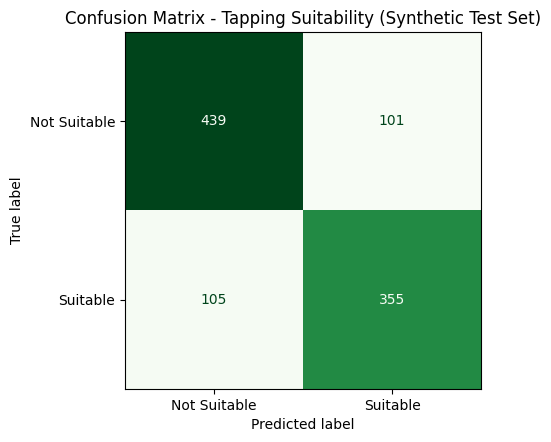

In [9]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Suitable", "Suitable"])
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(cmap="Greens", ax=ax, colorbar=False)
plt.title("Confusion Matrix - Tapping Suitability (Synthetic Test Set)")
plt.tight_layout()
plt.show()


Feature importance (%):
humidity         31.15
soil_moisture    30.48
temperature      25.38
rain             12.98
dtype: float64


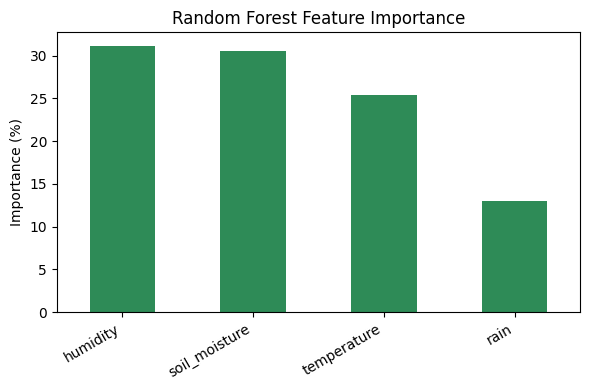

In [10]:
importances = pd.Series(model.feature_importances_, index=FEATURE_COLUMNS)
importances = (importances * 100).sort_values(ascending=False).round(2)

print("Feature importance (%):")
print(importances)

plt.figure(figsize=(6, 4))
importances.plot(kind="bar", color="seagreen")
plt.ylabel("Importance (%)")
plt.title("Random Forest Feature Importance")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


> **Important limitation (Section 17 / 29):** these numbers are computed on a
> synthetic test set and only demonstrate that the ML pipeline can learn a
> nonlinear relationship between environmental features and the synthetic
> label. They must **not** be presented as real-world tapping accuracy.


## 8. Model Serialization

The trained model is serialized with Joblib so the FastAPI backend can load
it once at startup instead of retraining for every request (Section 18).


In [11]:
os.makedirs("ml", exist_ok=True)
MODEL_PATH = "ml/tapping_model.pkl"

joblib.dump(model, MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")


Model saved to ml/tapping_model.pkl


In [12]:
# Sanity check: reload the model and run a single example prediction
loaded_model = joblib.load(MODEL_PATH)

sample = pd.DataFrame([{
    "temperature": 29.4,
    "humidity": 83,
    "soil_moisture": 48,
    "rain": 0,
}])

pred = loaded_model.predict(sample)[0]
prob = loaded_model.predict_proba(sample)[0][1]

print("Prediction :", "Suitable" if pred == 1 else "Not Suitable")
print(f"Probability: {prob:.2f}")


Prediction : Suitable
Probability: 0.96


## 9. ML Model Deployment — FastAPI Backend

The trained model is served through a FastAPI backend exposing `/predict`,
`/health` and `/fire-alert` endpoints (Section 19 and Section 23). The cells
below **write** the backend source files to disk with `%%writefile` — they
are not meant to be executed as a live server inside this notebook. Run the
backend separately with:

```bash
cd backend
pip install -r requirements.txt
uvicorn app:app --host 0.0.0.0 --port 8000
```


In [13]:
os.makedirs("backend", exist_ok=True)


In [14]:
%%writefile backend/requirements.txt
fastapi
uvicorn[standard]
scikit-learn
pandas
numpy
joblib
twilio


Writing backend/requirements.txt


In [15]:
%%writefile backend/app.py
"""
FastAPI backend for the ML-Enabled IoT-Based Rubber Plantation
Monitoring and Tapping Decision System (report Section 19).

Endpoints:
    GET  /health       - basic health check
    POST /predict       - tapping-suitability prediction from sensor data
    POST /fire-alert    - triggered by the ESP32 when the flame sensor fires
"""

import os

import joblib
import pandas as pd
from fastapi import FastAPI
from pydantic import BaseModel

from notifications import send_sms

MODEL_PATH = os.getenv("MODEL_PATH", "../ml/tapping_model.pkl")
NOT_SUITABLE_ALERT_RECIPIENT = os.getenv("ALERT_PHONE_NUMBER", "+10000000000")

app = FastAPI(title="Rubber Plantation Tapping Prediction API")

model = joblib.load(MODEL_PATH)


class SensorInput(BaseModel):
    temperature: float
    humidity: float
    soil_moisture: float
    rain: int


class FireAlertInput(BaseModel):
    event: str
    message: str


@app.get("/health")
def health_check():
    return {"status": "ok"}


@app.post("/predict")
def predict(data: SensorInput):
    features = pd.DataFrame([data.dict()])

    prediction = model.predict(features)[0]
    probability = float(model.predict_proba(features)[0][1])
    label = "Suitable" if prediction == 1 else "Not Suitable"

    # Example notification policy (Section 22): notify when NOT suitable.
    if label == "Not Suitable":
        message = (
            "Rubber plantation conditions are currently NOT SUITABLE for "
            f"tapping. Temp: {data.temperature}C, Humidity: {data.humidity}%, "
            f"Soil Moisture: {data.soil_moisture}%, Rain: "
            f"{'Yes' if data.rain else 'No'}. Probability: {probability:.2f}."
        )
        send_sms(NOT_SUITABLE_ALERT_RECIPIENT, message)

    return {"prediction": label, "probability": round(probability, 2)}


@app.post("/fire-alert")
def fire_alert(data: FireAlertInput):
    """
    Called by the ESP32 fire-safety subsystem (report Section 23) as a
    best-effort notification. The buzzer/relay/pump response on the ESP32
    itself does not wait on this call.
    """
    send_sms(NOT_SUITABLE_ALERT_RECIPIENT, data.message)
    return {"status": "alert_sent", "event": data.event}


Writing backend/app.py


In [16]:
%%writefile backend/notifications.py
"""
Twilio SMS integration for the rubber plantation monitoring backend
(report Section 22).

Credentials are read from environment variables so they are never hard-coded
into source files:
    TWILIO_ACCOUNT_SID
    TWILIO_AUTH_TOKEN
    TWILIO_FROM_NUMBER
"""

import os

from twilio.rest import Client

TWILIO_ACCOUNT_SID = os.getenv("TWILIO_ACCOUNT_SID")
TWILIO_AUTH_TOKEN = os.getenv("TWILIO_AUTH_TOKEN")
TWILIO_FROM_NUMBER = os.getenv("TWILIO_FROM_NUMBER")


def send_sms(to_number: str, message: str) -> bool:
    """Send an SMS notification through Twilio. Returns True on success."""
    if not (TWILIO_ACCOUNT_SID and TWILIO_AUTH_TOKEN and TWILIO_FROM_NUMBER):
        print("Twilio credentials not configured; skipping SMS send.")
        print(f"[SMS -> {to_number}]: {message}")
        return False

    try:
        client = Client(TWILIO_ACCOUNT_SID, TWILIO_AUTH_TOKEN)
        client.messages.create(body=message, from_=TWILIO_FROM_NUMBER, to=to_number)
        return True
    except Exception as exc:  # pragma: no cover - network/credential errors
        print(f"Failed to send SMS: {exc}")
        return False


Writing backend/notifications.py


## 10. Conclusion

This notebook covers the complete Python-side pipeline described in the
report: synthetic dataset generation with a nonlinear suitability function,
preprocessing, an 80/20 stratified train/test split, Random Forest training,
evaluation (Accuracy, Precision, Recall, F1-score, Confusion Matrix, Feature
Importance), model serialization with Joblib, and the FastAPI + Twilio
backend source files used to serve real-time predictions and notifications
to the ESP32-based IoT system.

As noted throughout, the evaluation figures are based on **synthetic data**
and are valid only for validating the ML pipeline. The next step toward a
scientifically meaningful system is retraining on real field-collected
sensor data paired with actual tapping outcomes and latex-yield measurements
(report Section 30).
